In [3]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.stats import kurtosis, skew

In [5]:
data_path = r"D:\Class Material\raw_data"

In [7]:
sample_file = os.path.join(data_path, "B007_1_123.mat", "B007_1_123.mat")
mat = loadmat(sample_file)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X123_DE_time', 'X123_FE_time', 'X123RPM'])


In [9]:
def get_signal(mat_file):
    data = loadmat(mat_file)
    
    for key in data.keys():
        if "DE_time" in key:
            return data[key].flatten()
    
    return None

In [11]:
def segment_signal(signal, window_size=2048):
    segments = []
    
    for i in range(0, len(signal) - window_size, window_size):
        segments.append(signal[i:i+window_size])
    
    return segments

In [13]:
def extract_features(signal):
    features = []
    
    # Time-domain
    rms = np.sqrt(np.mean(signal**2))
    mean = np.mean(signal)
    std = np.std(signal)
    var = np.var(signal)
    peak = np.max(np.abs(signal))
    
    kurt = kurtosis(signal)
    sk = skew(signal)
    
    crest_factor = peak / rms
    impulse_factor = peak / np.mean(np.abs(signal))
    shape_factor = rms / np.mean(np.abs(signal))
    
    # Frequency-domain
    fft_vals = np.abs(np.fft.fft(signal))
    freqs = np.fft.fftfreq(len(signal))
    
    dominant_freq = freqs[np.argmax(fft_vals)]
    spectral_energy = np.sum(fft_vals**2)
    spectral_entropy = -np.sum((fft_vals/np.sum(fft_vals)) * np.log(fft_vals/np.sum(fft_vals) + 1e-10))
    
    features.extend([
        rms, mean, std, var, peak,
        kurt, sk,
        crest_factor, impulse_factor, shape_factor,
        dominant_freq, spectral_energy, spectral_entropy
    ])
    
    return features

In [29]:
folder_to_label = {}
label_counter = 0

for folder in sorted(os.listdir(data_path)):
    folder_path = os.path.join(data_path, folder)
    
    if os.path.isdir(folder_path):
        folder_to_label[folder] = label_counter
        label_counter += 1

print(folder_to_label)

{'B007_1_123.mat': 0, 'B014_1_190.mat': 1, 'B021_1_227.mat': 2, 'IR007_1_110.mat': 3, 'IR014_1_175.mat': 4, 'IR021_1_214.mat': 5, 'OR007_6_1_136.mat': 6, 'OR014_6_1_202.mat': 7, 'OR021_6_1_239.mat': 8, 'Time_Normal_1_098.mat': 9}


In [31]:
X = []
y = []

for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)
    
    if not os.path.isdir(folder_path):
        continue
    
    for file in os.listdir(folder_path):
        if file.endswith(".mat"):
            
            file_path = os.path.join(folder_path, file)
            
            signal = get_signal(file_path)
            
            if signal is None:
                continue
            
            segments = segment_signal(signal)
            
            label = folder_to_label[folder]
            
            for seg in segments:
                features = extract_features(seg)
                X.append(features)
                y.append(label)

In [32]:
X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2369, 13)
Shape of y: (2369,)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9725738396624473


In [39]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[47  0  0  0  0  0  0  3  0  0]
 [ 0 44  1  0  0  0  0  0  0  0]
 [ 1  0 46  0  0  1  0  4  0  0]
 [ 0  0  0 53  0  0  0  0  0  0]
 [ 0  0  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 49  0  0  0  0]
 [ 0  0  0  0  0  0 51  0  0  0]
 [ 2  0  1  0  0  0  0 45  0  0]
 [ 0  0  0  0  0  0  0  0 43  0]
 [ 0  0  0  0  0  0  0  0  0 38]]

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        50
           1       1.00      0.98      0.99        45
           2       0.96      0.88      0.92        52
           3       1.00      1.00      1.00        53
           4       1.00      1.00      1.00        45
           5       0.98      1.00      0.99        49
           6       1.00      1.00      1.00        51
           7       0.87      0.94      0.90        48
           8       1.00      1.00      1.00        43
           9       1.00      1.00      1.00        38

    accuracy                 

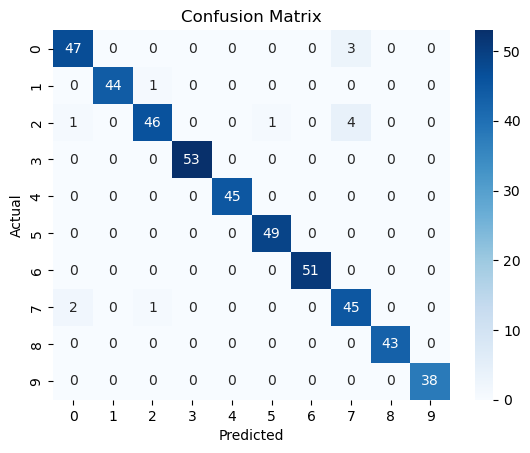

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()